# 2.Deep Learning Fraud Detection System
**(Sequential Financial Transactions)**

Dataset
**Credit Card Fraud Detection Dataset**

**Project Goal**
- Predict fraudulent transactions from sequential customer activity.

## **Task 1: Business Understanding**
Students must answer:
- Why is fraud detection difficult?
- Why is accuracy alone misleading?

"""
Why is fraud detection difficult?

1. Fraud transactions are extremely rare.
2. Fraudsters continuously change behavior patterns.
3. Fraud transactions often resemble legitimate transactions.
4. Real-time detection is computationally difficult.
5. High false positives affect customer trust.

Why is accuracy alone misleading?

1. Fraud datasets are highly imbalanced.
2. Example:
   99.8% transactions are legitimate.
3. A model predicting everything as legitimate
   can still achieve very high accuracy.
4. Therefore:
   Precision
   Recall
   F1-Score
   ROC-AUC
are more important than accuracy alone.
"""

## **Task 2: Exploratory Analysis**

Find:
- Fraud %
- Legitimate %
- Class imbalance ratio
- Visualizations:
- Transaction Amount Distribution
- Fraud vs Non-Fraud
- Correlation Heatmap

In [34]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
# FIX RANDOM SEEDS

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


In [ ]:
# LOAD DATASET

import kagglehub

path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [88]:
# SAVE SAMPLE CSV FOR STREAMLIT

sample_df = df.head(100)

sample_df.to_csv(
    "sample_transactions.csv",
    index=False
)

print("sample_transactions.csv saved")

sample_transactions.csv saved


In [37]:
# FRAUD %

fraud_percentage = (
    df["Class"].mean()
) * 100

print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.1727485630620034


In [38]:
# LEGITIMATE %

legitimate_percentage = 100 - fraud_percentage

print(
    "Legitimate Percentage:",
    legitimate_percentage
)

Legitimate Percentage: 99.827251436938


In [ ]:
# CLASS IMBALANCE RATIO

fraud_count = df["Class"].value_counts()[1]
legit_count = df["Class"].value_counts()[0]
imbalance_ratio = legit_count / fraud_count
print("Class Imbalance Ratio:", imbalance_ratio)

Class Imbalance Ratio: 577.8760162601626


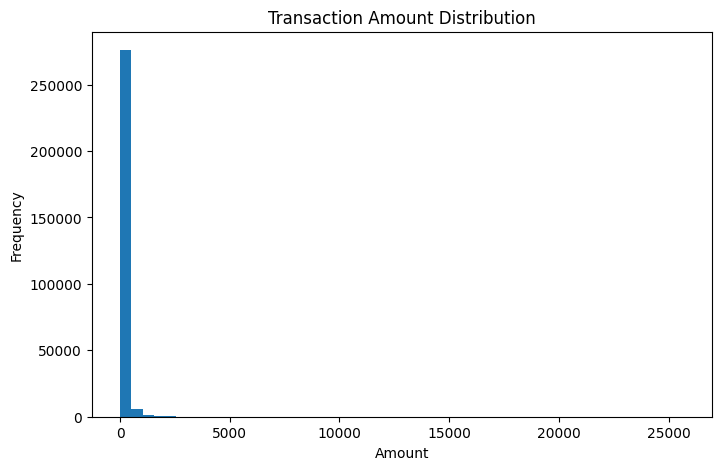

In [ ]:
# TRANSACTION AMOUNT DISTRIBUTION

plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

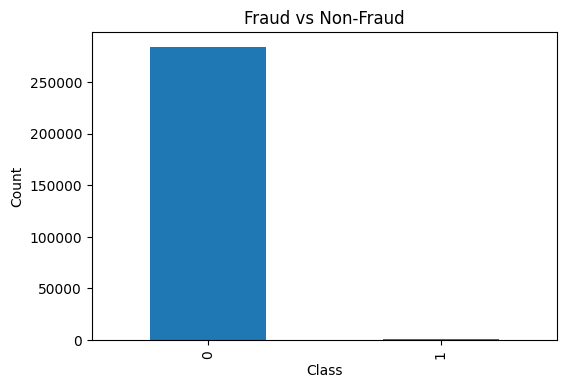

In [ ]:
# FRAUD VS NON-FRAUD

plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


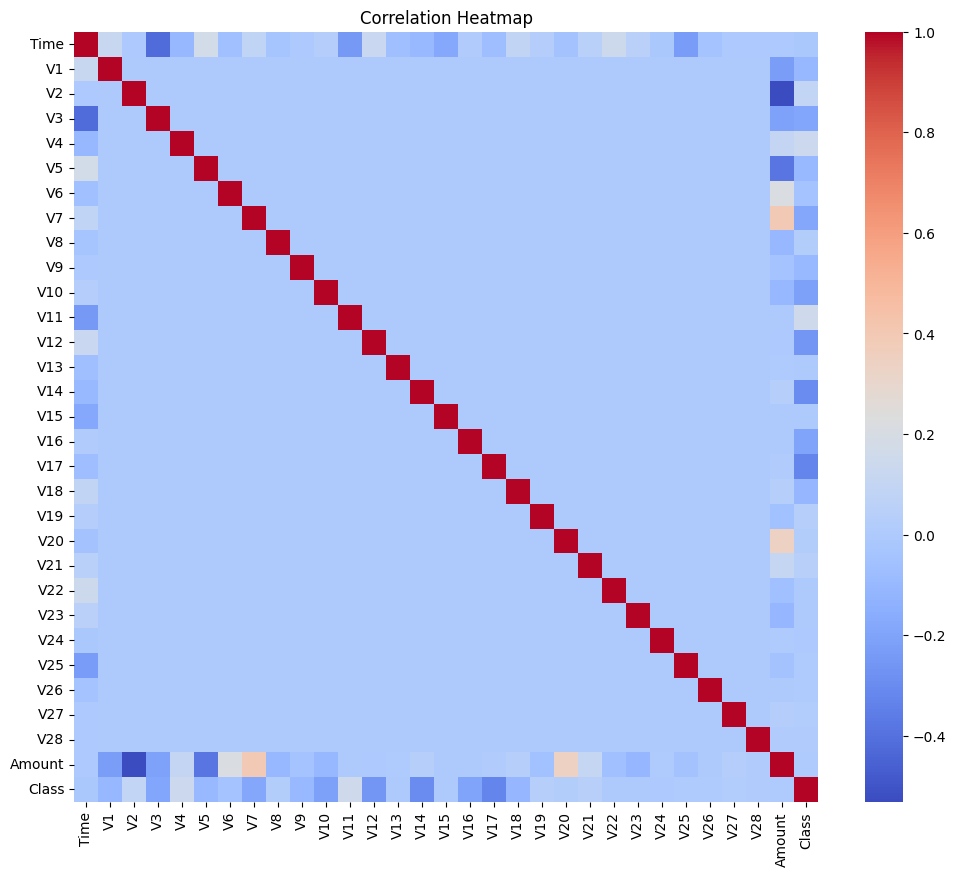

In [ ]:
# CORRELATION HEATMAP

plt.figure(figsize=(12,10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## **Task 3: Sequence Generation**
Create customer transaction sequences.

Example:
- Txn1
- Txn2
- Txn3
- Txn4
- ↓
- Predict Txn5 Fraud?

In [ ]:
from sklearn.utils import class_weight

# SORT BY TIME
df = df.sort_values("Time")

# FEATURES AND LABELS
X = df.drop("Class", axis=1)
y = df["Class"]

In [44]:
# TRAIN TEST SPLIT

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# SCALE DATA

scaler = StandardScaler()

X_train_raw["Amount"] = scaler.fit_transform(
    X_train_raw[["Amount"]]
)

X_test_raw["Amount"] = scaler.transform(
    X_test_raw[["Amount"]]
)

In [46]:
# CONVERT TO NUMPY

X_train_raw = X_train_raw.values
X_test_raw = X_test_raw.values

y_train_raw = y_train_raw.values
y_test_raw = y_test_raw.values

In [ ]:
# CREATE SEQUENCES

SEQUENCE_LENGTH = 5

def create_sequences(X, y, seq_len):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):
        X_seq.append(
            X[i:i+seq_len]
        )

        y_seq.append(
            y[i+seq_len]
        )

    return np.array(X_seq), np.array(y_seq)

In [ ]:
X_train, y_train = create_sequences(
    X_train_raw,
    y_train_raw,
    SEQUENCE_LENGTH
)

X_test, y_test = create_sequences(
    X_test_raw,
    y_test_raw,
    SEQUENCE_LENGTH
)

print(X_train.shape)
print(y_train.shape)

(227840, 5, 30)
(227840,)


In [49]:
# CLASS WEIGHTS

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5008661396551269), 1: np.float64(289.1370558375635)}


## **Task 4: Build Models**
Compare:

Model A
- Dense Network

Model B
- LSTM

Model C
- LSTM + Attention

In [ ]:
# TASK 4 : BUILD MODELS
# =====================================================

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Flatten,
    Input,
    MultiHeadAttention,
    Add,
    LayerNormalization,
    GlobalAveragePooling1D
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [ ]:
# =====================================================
# MODEL A : DENSE NETWORK
# =====================================================

model_dense = Sequential([
    Flatten(input_shape=X_train.shape[1:]),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model_dense.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
history_dense = model_dense.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4961 - loss: 952.1096 - val_accuracy: 0.1368 - val_loss: 0.6662
Epoch 2/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.2717 - loss: 4.7742 - val_accuracy: 0.0017 - val_loss: 0.7248
Epoch 3/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.1145 - loss: 1.9937 - val_accuracy: 0.0017 - val_loss: 0.7217
Epoch 4/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3109 - loss: 3.9657 - val_accuracy: 0.0017 - val_loss: 0.7162


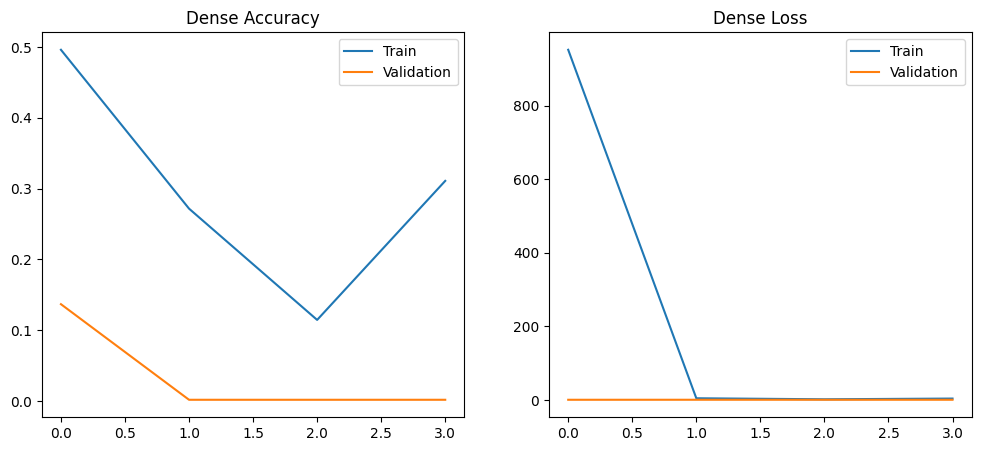

In [ ]:
# DENSE GRAPH

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])
plt.title("Dense Accuracy")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(history_dense.history['loss'])
plt.plot(history_dense.history['val_loss'])
plt.title("Dense Loss")
plt.legend(["Train","Validation"])
plt.show()

In [81]:
# DENSE EVALUATION

prob_dense = model_dense.predict(X_test)
pred_dense = (prob_dense > 0.5).astype(int)
accuracy_dense = np.mean(
    pred_dense.flatten() == y_test
)

print("Dense Accuracy:", accuracy_dense)

print(classification_report(
    y_test,
    pred_dense
))

print(
    "Dense ROC-AUC:",
    roc_auc_score(y_test, prob_dense)
)

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step
Dense Accuracy: 0.13675228681285884
              precision    recall  f1-score   support

           0       1.00      0.14      0.24     56859
           1       0.00      0.87      0.00        98

    accuracy                           0.14     56957
   macro avg       0.50      0.50      0.12     56957
weighted avg       1.00      0.14      0.24     56957

Dense ROC-AUC: 0.4968010736189163


In [ ]:
# =====================================================
# MODEL B : LSTM
# =====================================================

model_lstm = Sequential([
    LSTM(64, input_shape=X_train.shape[1:]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.7575 - loss: 0.7618 - val_accuracy: 0.9983 - val_loss: 0.6760
Epoch 2/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5322 - loss: 0.6956 - val_accuracy: 0.0017 - val_loss: 0.7456
Epoch 3/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.4100 - loss: 0.6966 - val_accuracy: 0.0017 - val_loss: 0.7338


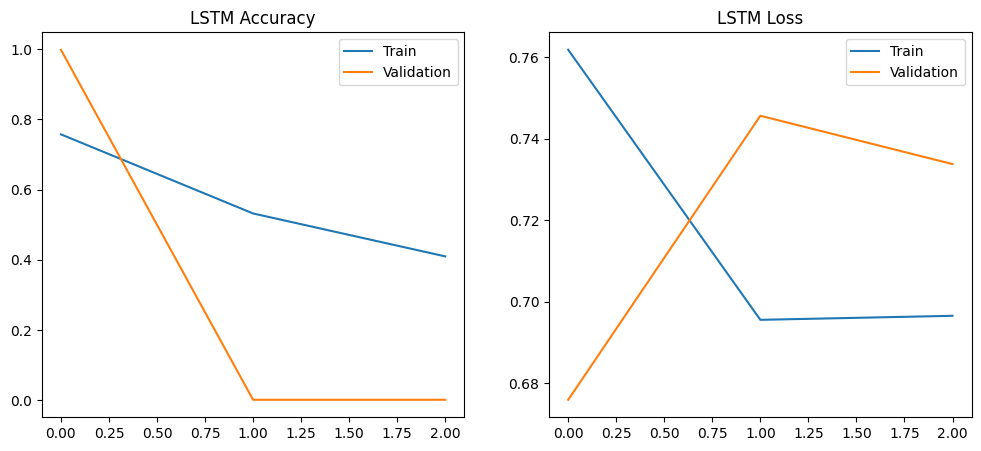

In [ ]:
# LSTM GRAPH

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title("LSTM Loss")
plt.legend(["Train","Validation"])
plt.show()




In [82]:
# LSTM EVALUATION

prob_lstm = model_lstm.predict(X_test)
pred_lstm = (prob_lstm > 0.5).astype(int)
accuracy_lstm = np.mean(
    pred_lstm.flatten() == y_test
)

print("LSTM Accuracy:", accuracy_lstm)

print(classification_report(
    y_test,
    pred_lstm
))

print(
    "LSTM ROC-AUC:",
    roc_auc_score(y_test, prob_lstm)
)


1780/1780 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
LSTM Accuracy: 0.9982794037607318
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56859
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56957
   macro avg       0.50      0.50      0.50     56957
weighted avg       1.00      1.00      1.00     56957

LSTM ROC-AUC: 0.4953302853352602


C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [62]:
# =====================================================
# MODEL C : LSTM + ATTENTION
# =====================================================

inputs = Input(shape=X_train.shape[1:])

x = LSTM(
    64,
    return_sequences=True
)(inputs)

attention_layer = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)

In [ ]:
attention_output = attention_layer(x, x)

x = Add()([x, attention_output])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)


In [64]:
model_attention = Model(
    inputs,
    outputs
)

model_attention.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [65]:
history_attention = model_attention.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)



Epoch 1/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.4298 - loss: 0.7537 - val_accuracy: 0.0017 - val_loss: 0.7418
Epoch 2/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.0031 - loss: 0.6940 - val_accuracy: 0.0017 - val_loss: 0.7184
Epoch 3/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.4289 - loss: 0.6936 - val_accuracy: 0.0017 - val_loss: 0.7114


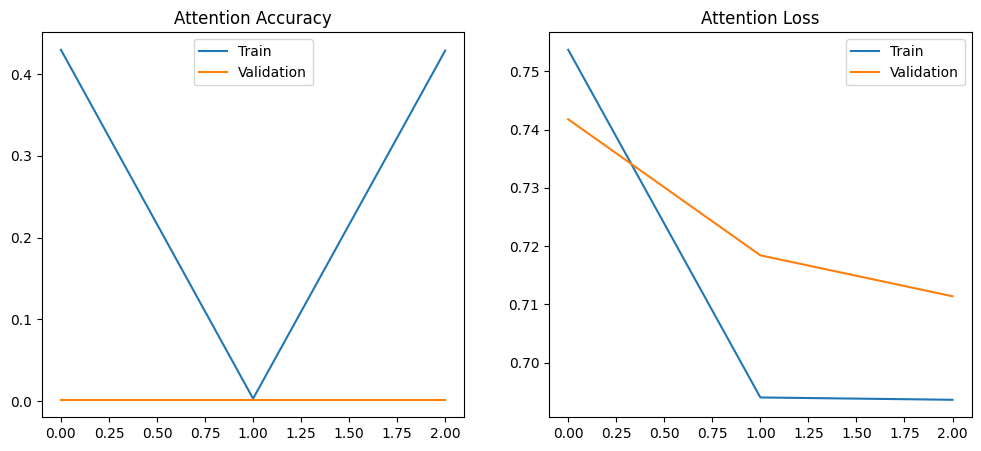

In [66]:
# ATTENTION GRAPH

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_attention.history['accuracy'])
plt.plot(history_attention.history['val_accuracy'])
plt.title("Attention Accuracy")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(history_attention.history['loss'])
plt.plot(history_attention.history['val_loss'])
plt.title("Attention Loss")
plt.legend(["Train","Validation"])
plt.show()



In [83]:
# ATTENTION EVALUATION

prob_attention = model_attention.predict(X_test)

pred_attention = (
    prob_attention > 0.5
).astype(int)
accuracy_attention = np.mean(
    pred_attention.flatten() == y_test
)

print(
    "Attention Accuracy:",
    accuracy_attention
)

print(classification_report(
    y_test,
    pred_attention
))

print(
    "Attention ROC-AUC:",
    roc_auc_score(y_test, prob_attention)
)

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Attention Accuracy: 0.0017205962392682198
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56859
           1       0.00      1.00      0.00        98

    accuracy                           0.00     56957
   macro avg       0.00      0.50      0.00     56957
weighted avg       0.00      0.00      0.00     56957

Attention ROC-AUC: 0.5


C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## **Task 5: Positional Encoding Experiment**
Add:
- Transaction Order Information
- before attention.
- Students must explain:
- Why order of transactions matters.

"""
Why order of transactions matters?

Fraud often depends on transaction sequence.

Example:

small purchases
- → sudden large withdrawal
- → international transfer

Positional Encoding helps the model
- understand transaction order.

In [68]:
# POSITIONAL ENCODING FUNCTION

def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dimensions = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(
        10000,
        (2 * (dimensions // 2)) / np.float32(d_model)
    )

    angle_rads = positions * angle_rates
    angle_rads[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    angle_rads[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)

In [69]:
# CUSTOM LAYER

class PositionalEncodingLayer(
    tf.keras.layers.Layer
):

    def __init__(self):
        super().__init__()

    def call(self, inputs):
        seq_len = inputs.shape[1]
        d_model = inputs.shape[2]
        pos_encoding = positional_encoding(
            seq_len,
            d_model
        )

        return inputs + pos_encoding


In [70]:
# MODEL

inputs = Input(shape=X_train.shape[1:])

x = PositionalEncodingLayer()(inputs)
x = LSTM(
    64,
    return_sequences=True
)(x)

In [71]:
attention_layer_pe = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)

attention_output_pe = attention_layer_pe(x, x)

x = Add()([x, attention_output_pe])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

In [72]:
model_pe = Model(inputs, outputs)

model_pe.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [73]:
history_pe = model_pe.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.3853 - loss: 0.7501 - val_accuracy: 0.0017 - val_loss: 0.7420
Epoch 2/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.2971 - loss: 0.7220 - val_accuracy: 0.0017 - val_loss: 0.7287
Epoch 3/10
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.2200 - loss: 0.6980 - val_accuracy: 0.0017 - val_loss: 0.7330


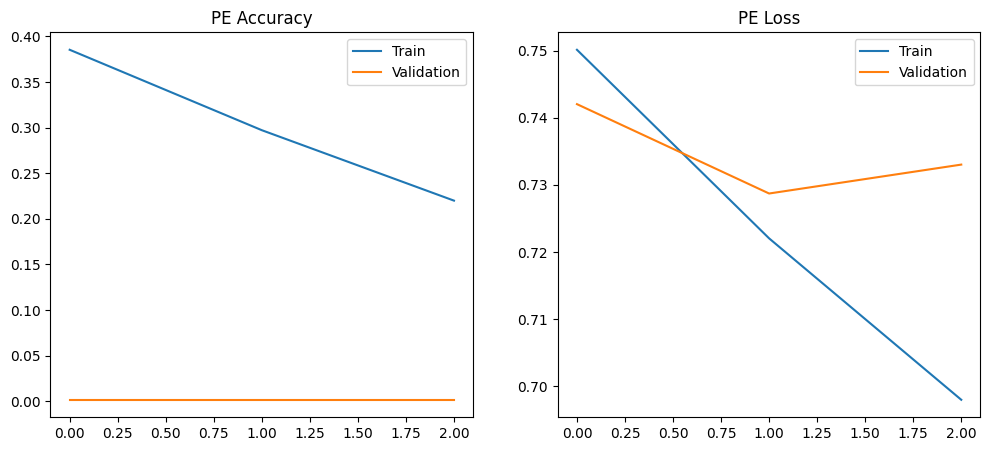

In [74]:
# GRAPH

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_pe.history['accuracy'])
plt.plot(history_pe.history['val_accuracy'])
plt.title("PE Accuracy")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(history_pe.history['loss'])
plt.plot(history_pe.history['val_loss'])
plt.title("PE Loss")
plt.legend(["Train","Validation"])
plt.show()



In [84]:
# EVALUATION

prob_pe = model_pe.predict(X_test)

pred_pe = (
    prob_pe > 0.5
).astype(int)
accuracy_pe = np.mean(
    pred_pe.flatten() == y_test
)

print(
    "Positional Encoding Accuracy:",
    accuracy_pe
)

print(classification_report(
    y_test,
    pred_pe
))

print(
    "PE ROC-AUC:",
    roc_auc_score(y_test, prob_pe)
)

1780/1780 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Positional Encoding Accuracy: 0.0017205962392682198
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56859
           1       0.00      1.00      0.00        98

    accuracy                           0.00     56957
   macro avg       0.00      0.50      0.00     56957
weighted avg       0.00      0.00      0.00     56957

PE ROC-AUC: 0.5064734963789769


C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    pred_dense
)
print("Accuracy:", accuracy)

print(classification_report(
    y_test,
    pred_dense
))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, prob_dense)
)

Accuracy: 0.13675228681285884
              precision    recall  f1-score   support

           0       1.00      0.14      0.24     56859
           1       0.00      0.87      0.00        98

    accuracy                           0.14     56957
   macro avg       0.50      0.50      0.12     56957
weighted avg       1.00      0.14      0.24     56957

ROC-AUC: 0.4968010736189163


## **Task 6: Attention Investigation**
Identify:
- Which transaction influenced fraud prediction most?


In [76]:
# EXTRACT ATTENTION

attention_extractor = Model(
    inputs=model_attention.input,
    outputs=attention_output
)

sample = X_test[0:1]
attention_scores = attention_extractor.predict(sample)
print(attention_scores.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
(1, 5, 64)


In [77]:
# IMPORTANCE SCORES

importance = np.mean(
    attention_scores[0],
    axis=-1
)
print("Importance Scores:")
print(importance)
most_important = np.argmax(importance)
print(
    "Most Important Transaction:",
    most_important
)


Importance Scores:
[-0.05824165 -0.05812998 -0.0581125  -0.05811018 -0.05810986]
Most Important Transaction: 4


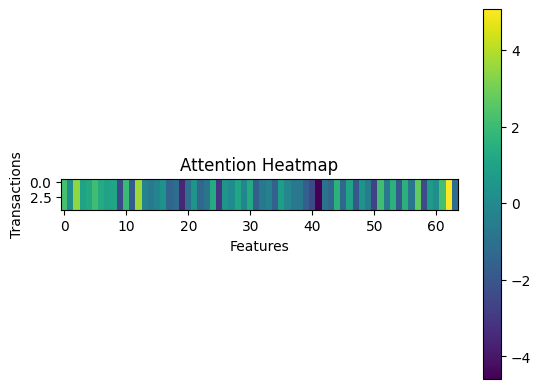

In [78]:
# HEATMAP

scores = np.squeeze(attention_scores)

plt.imshow(scores)
plt.title("Attention Heatmap")
plt.xlabel("Features")
plt.ylabel("Transactions")
plt.colorbar()
plt.show()

## **Task 7: Fraud Intelligence Dashboard**
Upload CSV

Show:
- Fraud Probability
- High Risk Transactions
- Attention Visualization

Bonus
- Real-time fraud detection simulation.

In [86]:
# SAVE MODEL

model_pe.save(
    "fraud_detection_model.keras"
)

In [87]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']